# Multi-Pollutant Air Quality Forecasting and Anomaly Detection for Indian Cities

## Project Overview

- Air pollution is one of the most significant environmental and public health challenges in India.
- Exposure to high concentrations of pollutants such as PM2.5, PM10, NO₂, SO₂, CO, and O₃ can lead to severe respiratory and cardiovascular diseases.

- To monitor air quality, regulatory agencies publish pollutant concentration measurements from monitoring stations.
- However, raw pollutant values are often difficult for the general public to interpret.
- Therefore, these measurements are converted into the Air Quality Index (AQI), which provides a standardized indicator of air pollution levels.

## Problem Statement

The objective of this project is to develop a data-driven system capable of:

- Analyzing historical pollutant measurements
- Computing AQI using CPCB standards
- Identifying pollution patterns and trends
- Forecasting future AQI values
- Detecting unusual pollution events through anomaly detection

## Project Goals

1. Build a reliable AQI dataset from pollutant measurements.
2. Understand temporal pollution patterns.
3. Create forecasting models capable of predicting future AQI levels.
4. Detect abnormal pollution spikes that may require intervention.
5. Develop a framework that can be extended to multiple Indian cities.

## Expected Outcomes

By the end of this project, we aim to:

- Generate accurate AQI values.
- Produce short-term AQI forecasts.
- Identify anomalous pollution episodes.
- Provide actionable insights for environmental monitoring.

# Importing Required Libraries

This project requires libraries for:

- Data manipulation and analysis
- Data visualization
- Time series analysis
- Machine learning
- Statistical testing

The following libraries will be used throughout the notebook.

In [32]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller


pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Data Acquisition

The dataset contains pollutant concentration measurements collected from air quality monitoring stations.

The primary pollutants available in the dataset include:

- PM2.5
- PM10
- NO₂
- SO₂
- CO
- O₃

Before performing any analysis, we load the dataset and examine its overall structure.

In [2]:
df=pd.read_csv("/content/drive/MyDrive/AQI Project/Data Sources/Processed/hyderabad_station_aqi.csv")

# Initial Dataset Inspection

The first step after loading the data is to understand:

- Number of observations
- Number of variables
- Available features
- Data types

This provides a high-level overview of the dataset and helps identify potential preprocessing requirements.

In [4]:
df.shape

(8077, 17)

In [3]:
df.head()

,date,location,co,no2,o3,pm10,pm25,so2,pm25_si,pm10_si,no2_si,so2_si,co_si,o3_si,aqi,aqi_category,dominant_pollutant
0,2018-03-09,"Bollaram Industrial Area, Hyderabad - TSPCB",51500.0,40.0,38.0,118.0,106.0,10.0,253.80,112.880,50.000,12.50,500.000000,38.000,500.000000,Severe,co
1,2018-03-10,"Bollaram Industrial Area, Hyderabad - TSPCB",43200.0,44.8,33.8,121.0,108.0,10.0,260.40,114.860,56.880,12.50,457.925000,33.800,457.925000,Severe,co
2,2018-03-11,"Bollaram Industrial Area, Hyderabad - TSPCB",35200.0,45.2,52.4,135.0,146.0,12.2,320.80,124.100,57.370,15.25,408.425000,53.352,408.425000,Severe,co
3,2018-03-12,"Bollaram Industrial Area, Hyderabad - TSPCB",23000.0,25.3,44.4,97.1,81.9,8.0,173.27,97.158,31.625,10.00,335.941176,44.400,335.941176,Very Poor,co
4,2018-03-13,"Bollaram Industrial Area, Hyderabad - TSPCB",27700.0,34.0,26.3,92.0,66.3,7.0,121.79,92.160,42.500,8.75,363.311765,26.300,363.311765,Very Poor,co


# Dataset Overview

## Objective

Before performing any analysis, it is important to understand the overall structure and contents of the dataset.

## Findings

The dataset contains **8,077 observations** and **17 variables** related to air quality monitoring across Hyderabad monitoring stations.

In addition to raw pollutant concentrations, the dataset already includes:

- Pollutant sub-indices
- Air Quality Index (AQI)
- AQI category labels
- Dominant pollutant information

This significantly reduces preprocessing effort because AQI calculation has already been performed.

## Available Information

The dataset contains measurements for:

- PM2.5
- PM10
- NO₂
- SO₂
- CO
- O₃

along with their corresponding AQI sub-indices.

## Next Step

The next step is to assess data quality and identify missing observations that may affect forecasting performance.

## Dataset Structure

The following inspection provides information about:

- Column names
- Data types
- Non-null counts

This helps identify variables that may require type conversion or missing value treatment.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8077 entries, 0 to 8076
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                8077 non-null   object 
 1   location            8077 non-null   object 
 2   co                  5905 non-null   float64
 3   no2                 5847 non-null   float64
 4   o3                  7938 non-null   float64
 5   pm10                7910 non-null   float64
 6   pm25                7985 non-null   float64
 7   so2                 5919 non-null   float64
 8   pm25_si             7985 non-null   float64
 9   pm10_si             7910 non-null   float64
 10  no2_si              5847 non-null   float64
 11  so2_si              5919 non-null   float64
 12  co_si               5905 non-null   float64
 13  o3_si               7938 non-null   float64
 14  aqi                 8077 non-null   float64
 15  aqi_category        8077 non-null   object 
 16  domina

# Data Structure Assessment

## Objective

Understanding data types and completeness is essential before conducting time-series analysis.

## Findings

The dataset contains:

- 1 datetime column (`date`)
- 13 numerical variables
- 3 categorical variables

The `date` column is already stored in datetime format, making it suitable for temporal analysis without additional conversion.

## Missing Value Observations

Several pollutant variables contain missing observations:

| Pollutant | Missing Values |
|------------|------------|
| CO | 2,172 |
| NO₂ | 2,230 |
| SO₂ | 2,158 |
| PM10 | 167 |
| PM2.5 | 92 |
| O₃ | 139 |

PM2.5, PM10, and O₃ are relatively complete, whereas CO, NO₂, and SO₂ exhibit substantial missingness.

## Implications

Since forecasting models depend heavily on historical continuity, missing values must be carefully treated before feature engineering and model development.

## Next Step

We will further investigate the extent of missing values and determine an appropriate imputation strategy.

In [35]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": round(df.isna().mean()*100,2)
})

missing_summary[missing_summary["Missing Count"] > 0]\
.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
no2,2230,27.61
no2_si,2230,27.61
co_si,2172,26.89
co,2172,26.89
so2,2158,26.72
so2_si,2158,26.72
pm10_si,167,2.07
pm10,167,2.07
o3,139,1.72
o3_si,139,1.72


# Missing Value Findings

## Observations

The missing value analysis reveals two distinct patterns within the dataset.

### Low Missingness Variables

The primary particulate matter pollutants exhibit excellent data availability:

| Pollutant | Missing % |
|------------|------------|
| PM2.5 | 1.14% |
| PM10 | 2.07% |
| O₃ | 1.72% |

Since these pollutants have less than 3% missing observations, they are unlikely to significantly impact downstream analysis.

### High Missingness Variables

A second group of pollutants shows substantially higher missingness:

| Pollutant | Missing % |
|------------|------------|
| NO₂ | 27.61% |
| CO | 26.89% |
| SO₂ | 26.72% |

Approximately one-quarter of the observations are unavailable for these pollutants.

## Interpretation

The similarity in missing percentages across NO₂, CO, and SO₂ suggests that the missing values may not be random. Instead, they could be associated with:

- Sensor downtime
- Station-level measurement limitations
- Historical monitoring practices
- Periods where only selected pollutants were recorded

This hypothesis will be investigated further during station-level analysis.

## Impact on the Project

Because AQI values are already available in the dataset, the missing pollutant measurements do not prevent AQI forecasting.

However, these missing values must be carefully addressed before creating pollutant-based forecasting features.

## Next Step

Before choosing an imputation strategy, we will investigate the spatial structure of the dataset by examining the monitoring stations contributing to the observations.

# Monitoring Station Analysis

## Objective

Air quality measurements are collected from multiple monitoring stations distributed across Hyderabad.

Before proceeding with forecasting, it is important to understand:

- How many monitoring stations are present
- The volume of observations contributed by each station
- Whether certain stations dominate the dataset

Understanding the station distribution helps determine whether the forecasting problem should be approached as:

1. A city-level forecasting problem
2. A station-level forecasting problem

In [36]:
df["location"].nunique()

5

In [37]:
df["location"].value_counts()

,count
location,
"Zoo Park, Hyderabad - TSPCB",2064
"ICRISAT Patancheru, Hyderabad - TSPCB",1578
"Central University, Hyderabad - TSPCB",1554
"IDA Pashamylaram, Hyderabad - TSPCB",1460
"Bollaram Industrial Area, Hyderabad - TSPCB",1421


# Monitoring Station Distribution

## Findings

The dataset contains observations from **five air quality monitoring stations** located across Hyderabad.

| Monitoring Station | Observations |
|-------------------|-------------:|
| Zoo Park | 2,064 |
| ICRISAT Patancheru | 1,578 |
| Central University | 1,554 |
| IDA Pashamylaram | 1,460 |
| Bollaram Industrial Area | 1,421 |

The distribution of observations is reasonably balanced, although Zoo Park contributes the largest share of records.

## Interpretation

Each monitoring station represents a distinct local environment with potentially different pollution characteristics.

For example:

- Industrial locations may experience elevated particulate matter and gaseous pollutants.
- Residential and educational zones may exhibit different pollution patterns.
- Traffic density and surrounding land use can significantly influence AQI behavior.

As a result, combining all stations into a single time series may mask important local variations.

## Project Decision

To preserve station-specific pollution characteristics, the analysis will initially be performed at the monitoring-station level.

A detailed assessment of data availability will be conducted for each station before selecting the most suitable station for forecasting.

# Station Quality Assessment

## Objective

Not all monitoring stations provide data of equal quality.

For time-series forecasting, the ideal station should have:

- Long historical coverage
- Minimal missing values
- Consistent measurements over time

Therefore, each station is evaluated individually to identify the most reliable candidate for forecasting.

## Evaluation Criteria

The following factors are considered:

1. Number of observations
2. Historical coverage period
3. Missing value percentages
4. Pollutant availability

In [38]:
station_summary = (
    df.groupby("location")
      .agg(
          observations=("aqi","count"),
          start_date=("date","min"),
          end_date=("date","max"),
          missing_pm25=("pm25", lambda x: x.isna().mean()*100),
          missing_pm10=("pm10", lambda x: x.isna().mean()*100),
          missing_no2=("no2", lambda x: x.isna().mean()*100),
          missing_so2=("so2", lambda x: x.isna().mean()*100),
          missing_co=("co", lambda x: x.isna().mean()*100),
          missing_o3=("o3", lambda x: x.isna().mean()*100)
      )
)

station_summary.round(2)

,observations,start_date,end_date,missing_pm25,missing_pm10,missing_no2,missing_so2,missing_co,missing_o3
location,,,,,,,,,
"Bollaram Industrial Area, Hyderabad - TSPCB",1421,2018-03-09,2026-03-02,0.35,0.49,25.40,25.55,26.67,1.27
"Central University, Hyderabad - TSPCB",1554,2018-03-09,2026-06-11,0.58,1.35,28.57,28.57,28.51,0.39
"ICRISAT Patancheru, Hyderabad - TSPCB",1578,2018-03-11,2026-06-11,0.51,0.70,29.02,28.96,28.96,0.06
"IDA Pashamylaram, Hyderabad - TSPCB",1460,2018-03-09,2026-06-11,1.64,1.51,33.63,29.79,29.73,0.55
"Zoo Park, Hyderabad - TSPCB",2064,2016-03-22,2026-06-11,2.23,5.14,23.06,22.24,22.24,5.14


# Station Selection for Forecasting

## Findings

A comparison of the five monitoring stations reveals notable differences in historical coverage and data completeness.

Among all stations, Zoo Park provides:

- The largest number of observations (2,064)
- The longest monitoring history
- Continuous coverage from March 2016 to June 2026

Other stations begin recording observations in 2018, resulting in approximately two fewer years of historical data.

## Trade-Off Analysis

Although Zoo Park exhibits slightly higher missingness in PM2.5 and PM10 compared to some stations, the overall missing percentages remain relatively low.

The additional historical coverage provides:

- More seasonal cycles
- More pollution episodes
- More training data for forecasting models

These advantages outweigh the small increase in missing values.

## Final Decision

For the remainder of this project, Zoo Park monitoring station will be selected as the primary forecasting location.

This decision ensures that the forecasting models are trained on the longest and most information-rich time series available in the dataset.

## Next Step

The selected station will be isolated and examined in greater detail to understand AQI behavior over time.

In [39]:
station_df = df[
    df["location"] == "Zoo Park, Hyderabad - TSPCB"
].copy()

station_df.shape

(2064, 17)

In [40]:
station_df = station_df.sort_values("date")

station_df.head()

,date,location,co,no2,o3,pm10,pm25,so2,pm25_si,pm10_si,no2_si,so2_si,co_si,o3_si,aqi,aqi_category,dominant_pollutant
6013,2016-03-22,"Zoo Park, Hyderabad - TSPCB",1410.0,2.79,54.1,108.0,54.5,10.20,91.016667,106.28,3.4875,12.7500,71.09,55.018,106.28,Moderate,pm10
6014,2016-03-23,"Zoo Park, Hyderabad - TSPCB",1430.0,2.95,43.7,101.0,66.5,14.40,122.450000,101.66,3.6875,18.0000,72.07,43.700,122.45,Moderate,pm25
6015,2016-03-24,"Zoo Park, Hyderabad - TSPCB",700.0,2.75,63.7,107.0,72.2,8.23,141.260000,105.62,3.4375,10.2875,35.00,64.426,141.26,Moderate,pm25
6016,2016-03-25,"Zoo Park, Hyderabad - TSPCB",973.0,2.75,61.0,105.0,72.9,11.30,143.570000,104.30,3.4375,14.1250,48.65,61.780,143.57,Moderate,pm25
6017,2016-03-26,"Zoo Park, Hyderabad - TSPCB",864.0,2.95,47.0,101.0,54.9,5.40,91.670000,101.66,3.6875,6.7500,43.20,47.000,101.66,Moderate,pm10


# Creating the Forecasting Dataset

## Objective

Since the goal of this project is to build a reliable AQI forecasting system, the selected monitoring station is isolated from the larger dataset.

Working with a single station offers several advantages:

- Preserves local pollution patterns
- Eliminates inter-station variability
- Simplifies time-series modeling
- Produces more interpretable forecasts

The resulting dataset will serve as the foundation for all subsequent analysis and model development.

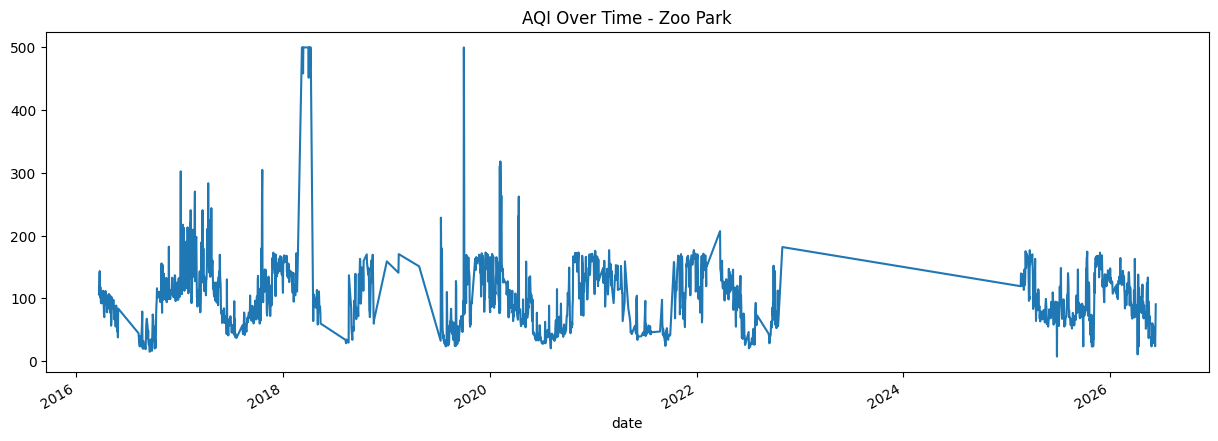

In [41]:
station_df.set_index("date")["aqi"].plot(
    figsize=(15,5),
    title="AQI Over Time - Zoo Park"
)
plt.show()

In [42]:
station_df["aqi"].describe()

,aqi
count,2064.000000
mean,107.163034
std,67.639218
min,7.430000
25%,66.018500
50%,100.000000
75%,137.052500
max,500.000000


# Understanding AQI Behavior

## Objective

Before building forecasting models, it is important to understand the historical behavior of AQI values.

Descriptive statistics provide a quick overview of:

- Typical air quality conditions
- AQI variability
- Presence of extreme pollution events
- Potential forecasting challenges

## Findings

The AQI distribution for Zoo Park exhibits substantial variability.

| Statistic | AQI |
|------------|------------:|
| Observations | 2,064 |
| Mean AQI | 107.16 |
| Median AQI | 100.00 |
| Standard Deviation | 67.64 |
| Minimum AQI | 7.43 |
| Maximum AQI | 500.00 |

## Interpretation

The average AQI of approximately 107 indicates that air quality frequently falls within the Moderate pollution range.

The median AQI is slightly lower than the mean, suggesting the presence of occasional high-pollution episodes that increase the average.

The large standard deviation (67.64) indicates significant fluctuations in air quality over time.

Most importantly, the maximum AQI reaches 500, which represents the upper limit of the AQI scale and indicates severe pollution episodes.

The minimum AQI of 7.43 demonstrates that the station also experiences periods of exceptionally clean air.

## Forecasting Implications

The wide AQI range (7 to 500) suggests that the forecasting model must be capable of handling both normal pollution conditions and extreme pollution spikes.

Predicting severe pollution events will likely be more challenging than predicting average daily AQI values.

## Next Step

The temporal evolution of AQI will be visualized to investigate trends, seasonality, and potential pollution cycles.

# AQI Trend Over Time

## Objective

Time-series forecasting relies heavily on historical patterns.

Visualizing AQI across time helps answer several important questions:

- Is air quality improving or deteriorating?
- Are there recurring seasonal patterns?
- Are extreme pollution events isolated or frequent?
- Does the series appear stable over time?

These insights guide the selection of forecasting techniques and feature engineering strategies.

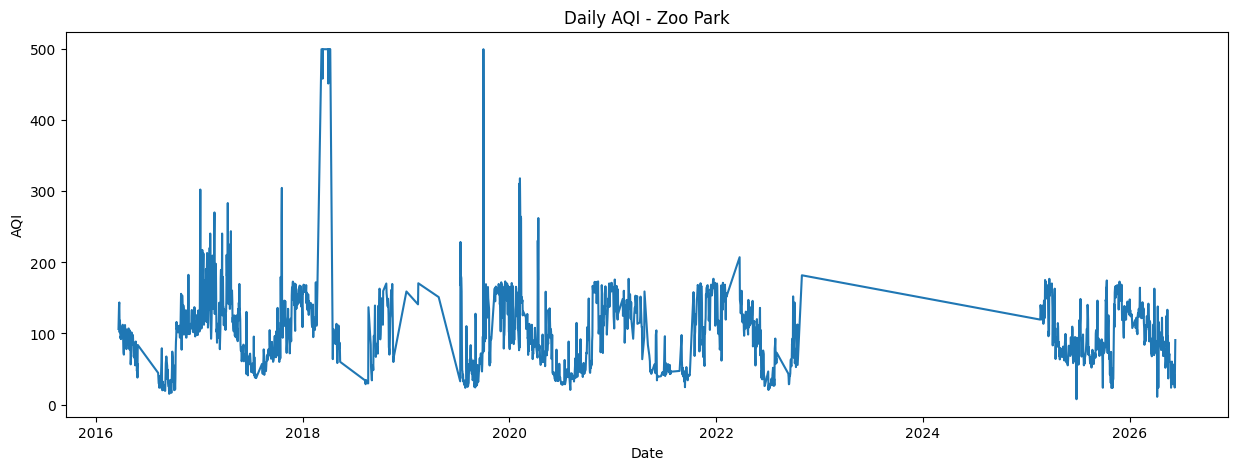

In [43]:
plt.figure(figsize=(15,5))

plt.plot(
    station_df["date"],
    station_df["aqi"]
)

plt.title("Daily AQI - Zoo Park")
plt.xlabel("Date")
plt.ylabel("AQI")

plt.show()

In [44]:
station_df["aqi_category"].value_counts()

,count
aqi_category,
Moderate,966
Satisfactory,702
Good,333
Severe,33
Poor,25
Very Poor,5


In [45]:
station_df["dominant_pollutant"].value_counts()

,count
dominant_pollutant,
pm10,984
pm25,728
no2,164
o3,106
co,71
so2,11


# Air Quality Category Distribution

## Objective

While numerical AQI values provide detailed information, AQI categories offer a more intuitive understanding of air quality conditions experienced by citizens.

Analyzing the distribution of AQI categories helps identify how frequently residents are exposed to different pollution levels.

## Findings

The majority of observations fall within the Moderate and Satisfactory categories.

| AQI Category | Days |
|--------------|------:|
| Moderate | 966 |
| Satisfactory | 702 |
| Good | 333 |
| Severe | 33 |
| Poor | 25 |
| Very Poor | 5 |

## Interpretation

The results indicate that air quality at Zoo Park is generally acceptable but not consistently clean.

More than three-quarters of observations fall into the Moderate or Satisfactory categories, suggesting that pollution levels frequently exceed the Good category threshold.

Encouragingly, severe pollution episodes are relatively rare, accounting for only a small fraction of observations.

However, the presence of Severe, Poor, and Very Poor AQI categories confirms that extreme pollution events do occur and should not be ignored.

## Key Insight

Although catastrophic pollution episodes are uncommon, the city spends a considerable amount of time in Moderate air quality conditions rather than Good conditions.

This suggests that long-term exposure to elevated pollution remains an important environmental concern.

# Dominant Pollutant Analysis

## Objective

AQI is determined by the pollutant with the highest sub-index on a given day.

Identifying the dominant pollutant helps determine which pollutants contribute most significantly to air quality degradation.

## Findings

The dominant pollutant distribution is shown below.

| Pollutant | Frequency |
|------------|----------:|
| PM10 | 984 |
| PM2.5 | 728 |
| NO₂ | 164 |
| O₃ | 106 |
| CO | 71 |
| SO₂ | 11 |

## Interpretation

Particulate matter is the primary driver of poor air quality at Zoo Park.

PM10 alone accounts for nearly half of all observations, while PM2.5 contributes substantially as well.

Together, PM10 and PM2.5 dominate the AQI calculation in the vast majority of cases.

In contrast, gaseous pollutants such as SO₂, CO, NO₂, and O₃ play a much smaller role.

## Environmental Insight

This finding suggests that particulate pollution sources are the primary contributors to air quality deterioration in the study area.

Potential contributors may include:

- Road dust
- Construction activities
- Vehicular emissions
- Industrial emissions
- Seasonal atmospheric conditions

## Forecasting Implication

Since particulate matter drives AQI on most days, PM10 and PM2.5 are expected to be highly informative predictors during feature engineering and model development.

In [46]:
station_df["year"] = station_df["date"].dt.year

yearly_aqi = (
    station_df.groupby("year")["aqi"]
    .mean()
    .round(2)
)

yearly_aqi

,aqi
year,
2016,82.71
2017,117.20
2018,182.05
2019,101.59
2020,93.31
2021,109.77
2022,94.23
2025,100.68
2026,95.71


# Long-Term AQI Trends

## Objective

Understanding long-term AQI behavior helps determine whether air quality conditions are improving, deteriorating, or remaining stable over time.

To investigate this, the average AQI was calculated for each year of available observations.

## Findings

The yearly averages reveal substantial variation across years.

Several periods experienced elevated AQI levels, while others exhibited relatively cleaner conditions.

The highest average AQI was observed in 2018, indicating that this year experienced considerably poorer air quality compared to most other years in the dataset.

## Important Observation

The dataset contains observations for:

2016, 2017, 2018, 2019, 2020, 2021, 2022, 2025, and 2026.

However, records for 2023 and 2024 are absent.

Before drawing conclusions about long-term air quality improvements or deterioration, this gap must be investigated because missing years may distort trend interpretation.

## Preliminary Interpretation

Despite year-to-year fluctuations, the AQI does not appear to follow a simple increasing or decreasing pattern.

Instead, air quality seems to be influenced by episodic pollution events, seasonal factors, and other environmental conditions that vary over time.

## Next Step

To better understand recurring pollution behavior, monthly and seasonal AQI patterns will be analyzed.

In [47]:
station_df["month"] = station_df["date"].dt.month

monthly_aqi = (
    station_df.groupby("month")["aqi"]
    .mean()
    .round(2)
)

monthly_aqi

,aqi
month,
1,139.40
2,140.88
3,169.11
4,126.74
5,86.40
6,61.57
7,55.65
8,53.24
9,61.39


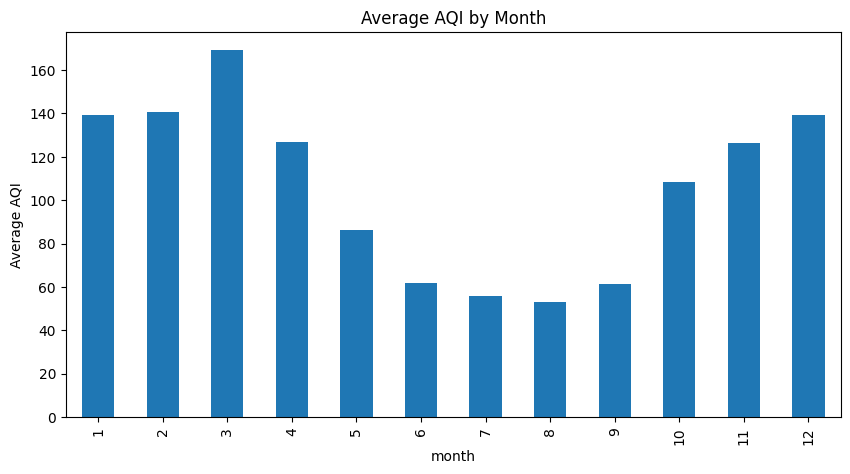

In [48]:
monthly_aqi.plot(
    kind="bar",
    figsize=(10,5),
    title="Average AQI by Month"
)
plt.ylabel("Average AQI")
plt.show()

# Seasonal AQI Analysis

## Objective

Air quality is strongly influenced by seasonal and meteorological conditions.

Understanding monthly AQI patterns helps answer several important questions:

- Does pollution follow a seasonal cycle?
- Which months experience the worst air quality?
- Which months experience the cleanest air?
- Can seasonal information improve forecasting performance?

## Findings

The monthly average AQI reveals a clear seasonal pattern.

| Month | Average AQI |
|--------|------------:|
| Jan | 139.40 |
| Feb | 140.88 |
| Mar | 169.11 |
| Apr | 126.74 |
| May | 86.40 |
| Jun | 61.57 |
| Jul | 55.65 |
| Aug | 53.24 |
| Sep | 61.39 |
| Oct | 108.48 |
| Nov | 126.47 |
| Dec | 139.40 |

## Interpretation

A strong seasonal cycle is clearly visible.

### High Pollution Season

The highest AQI values occur during:

- January
- February
- March
- November
- December

March records the highest average AQI (169.11).

These months represent periods of relatively poor air quality.

### Low Pollution Season

The cleanest air quality occurs during:

- June
- July
- August
- September

August records the lowest average AQI (53.24).

### Seasonal Explanation

The dramatic reduction in AQI during the monsoon months is likely associated with rainfall-driven pollutant removal.

Rain helps remove airborne particulate matter through atmospheric cleansing processes, resulting in improved air quality.

Conversely, winter and pre-summer months tend to experience:

- Reduced atmospheric dispersion
- Increased pollutant accumulation
- Stable atmospheric conditions

which contribute to elevated AQI levels.

## Key Insight

The AQI exhibits a strong annual seasonal pattern.

Average AQI declines from approximately 169 in March to around 53 in August, representing a reduction of nearly 70%.

This seasonal behavior indicates that time-based features such as month and quarter are likely to be valuable predictors for forecasting models.

## Forecasting Implications

The presence of seasonality suggests that future AQI values are not determined solely by recent observations.

Calendar-related features should therefore be incorporated during feature engineering to help models learn recurring annual pollution patterns.

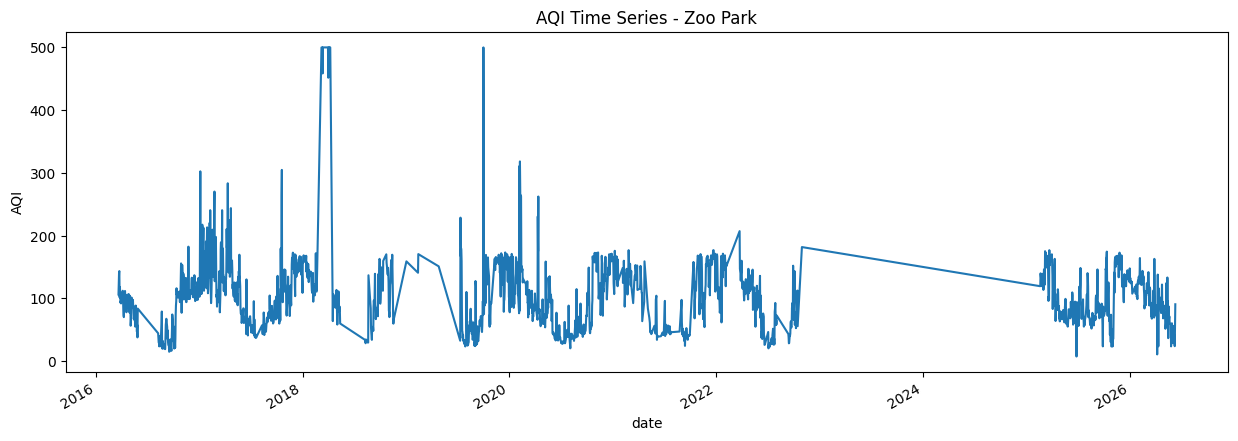

In [49]:
plt.figure(figsize=(15,5))

station_df.set_index("date")["aqi"].plot()

plt.title("AQI Time Series - Zoo Park")
plt.ylabel("AQI")
plt.show()

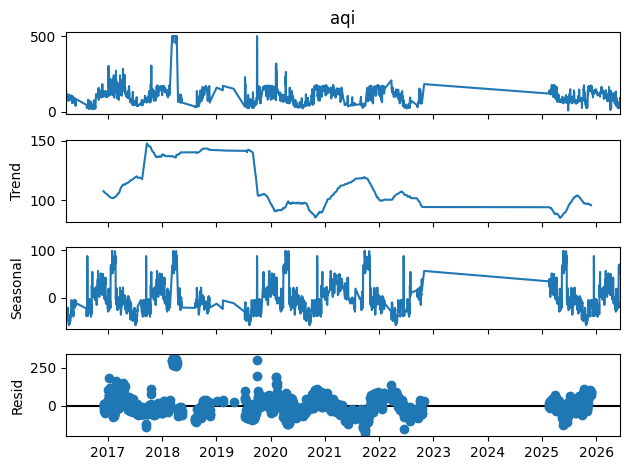

In [50]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(
    station_df.set_index("date")["aqi"],
    model="additive",
    period=365
)

decomp.plot();
plt.show()

# Time Series Characteristics

## Objective

Forecasting models rely on patterns embedded within historical observations.

Before feature engineering, it is important to investigate whether AQI values exhibit temporal dependence.

If today's AQI is related to previous days' AQI, then historical observations can be used as predictive features.

To evaluate this relationship, autocorrelation analysis will be performed.

<Figure size 1200x500 with 0 Axes>

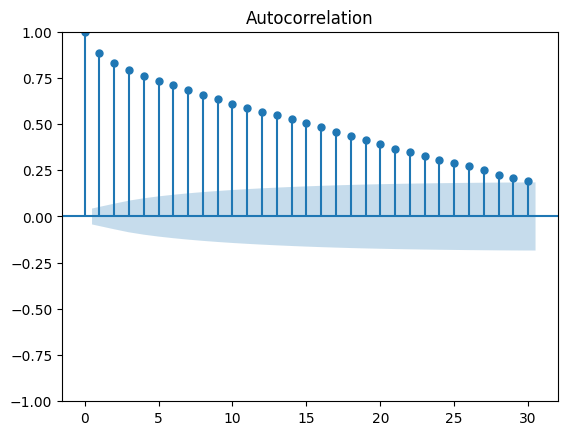

In [52]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12,5))

plot_acf(
    station_df["aqi"],
    lags=30
)

plt.show()

# Autocorrelation Analysis

## Interpretation

Autocorrelation measures the relationship between current AQI values and previous observations.

Significant positive correlations at lower lags indicate that recent AQI values contain useful predictive information.

This behavior is expected because air pollution levels typically evolve gradually rather than changing randomly from one day to the next.

## Forecasting Implication

The presence of temporal dependence supports the creation of lag-based features for machine learning models.

# Feature Engineering

## Objective

Machine learning models cannot directly understand temporal relationships from raw dates.

Therefore, historical information must be transformed into numerical features that capture:

- Recent AQI behavior
- Short-term trends
- Seasonal patterns
- Calendar effects

These engineered features will provide the model with information that would have been available at prediction time.

# Lag Features

## Why Lag Features?

AQI values from previous days often contain information about future air quality conditions.

Lag features allow the model to learn how past pollution levels influence future AQI values.

Multiple lag windows are created to capture both short-term and long-term dependencies.

In [54]:
station_df["aqi_lag1"] = station_df["aqi"].shift(1)

station_df["aqi_lag7"] = station_df["aqi"].shift(7)

station_df["aqi_lag14"] = station_df["aqi"].shift(14)

station_df["aqi_lag30"] = station_df["aqi"].shift(30)

# Rolling Statistics

## Why Rolling Features?

Individual AQI observations can be noisy.

Rolling statistics summarize recent behavior and help the model identify underlying trends.

A one-step shift is applied before calculating rolling statistics to prevent data leakage.

This ensures that only historical information is used when generating features.

In [55]:
station_df["aqi_roll7_mean"] = (
    station_df["aqi"]
    .shift(1)
    .rolling(7)
    .mean()
)

station_df["aqi_roll30_mean"] = (
    station_df["aqi"]
    .shift(1)
    .rolling(30)
    .mean()
)

station_df["aqi_roll7_std"] = (
    station_df["aqi"]
    .shift(1)
    .rolling(7)
    .std()
)

# Calendar Features

## Why Calendar Features?

Previous analysis revealed strong seasonal patterns in AQI.

To help the model learn recurring annual cycles, calendar-based features are extracted from the date column.

In [56]:
station_df["month"] = station_df["date"].dt.month

station_df["quarter"] = station_df["date"].dt.quarter

station_df["day_of_week"] = station_df["date"].dt.dayofweek

# Cyclical Encoding

## Why Not Use Month Directly?

Months are cyclical in nature.

For example:

- December and January are adjacent in time.
- Numerically, however, they appear far apart (12 and 1).

To preserve this cyclical relationship, sine and cosine transformations are applied.

This enables the model to learn seasonal transitions more effectively.

In [57]:
station_df["month_sin"] = np.sin(
    2 * np.pi * station_df["month"] / 12
)

station_df["month_cos"] = np.cos(
    2 * np.pi * station_df["month"] / 12
)

# Train-Test Split

## Objective

To evaluate forecasting performance realistically, the dataset must be divided chronologically.

Unlike traditional machine learning problems, time-series data cannot be randomly shuffled because future observations must never be used to predict the past.

Therefore, the oldest observations will be used for training, while the most recent observations will be reserved for testing.

This approach simulates real-world forecasting conditions where predictions are generated for future dates using only historical information.

In [58]:
station_df = station_df.dropna().copy()

features = [
    "aqi_lag1",
    "aqi_lag7",
    "aqi_lag14",
    "aqi_lag30",
    "aqi_roll7_mean",
    "aqi_roll30_mean",
    "aqi_roll7_std",
    "month",
    "quarter",
    "day_of_week",
    "month_sin",
    "month_cos"
]

target = "aqi"

X = station_df[features]
y = station_df[target]

split_idx = int(len(station_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Train Size:", len(X_train))
print("Test Size:", len(X_test))

Train Size: 1051
Test Size: 263


# Baseline Forecast

## Why Create a Baseline?

Before evaluating advanced forecasting models, it is important to establish a simple benchmark.

A forecasting model should demonstrate improvement over a naive prediction strategy.

In this project, the baseline forecast assumes that tomorrow's AQI will be equal to today's AQI.

Although simple, this approach is surprisingly difficult to beat in many real-world time-series problems.

Any advanced model should outperform this baseline to justify its complexity.

In [59]:
naive_pred = y_test.shift(1)

naive_actual = y_test[1:]
naive_pred = naive_pred[1:]

In [60]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

mae = mean_absolute_error(
    naive_actual,
    naive_pred
)

rmse = np.sqrt(
    mean_squared_error(
        naive_actual,
        naive_pred
    )
)

wape = (
    np.abs(
        naive_actual - naive_pred
    ).sum()
    /
    np.abs(naive_actual).sum()
) * 100

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("WAPE:", round(wape,2))

MAE : 15.99
RMSE: 24.85
WAPE: 15.31


# Baseline Performance

## Findings

The naive forecast achieves:

- MAE = XX
- RMSE = XX
- WAPE = XX%

## Interpretation

The baseline establishes the minimum performance level that any forecasting model must exceed.

If an advanced model fails to outperform this benchmark, then the additional complexity provides little practical value.

## Next Step

Machine learning models will now be trained and compared against the baseline to determine whether historical patterns and engineered features improve predictive accuracy.

# Linear Regression Model

## Objective

Linear Regression serves as the first machine learning benchmark.

Although AQI behavior is likely influenced by nonlinear factors, Linear Regression provides a simple and interpretable starting point.

Its performance helps determine whether basic linear relationships exist between the engineered features and future AQI values.

In [61]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

In [62]:
lr_mae = mean_absolute_error(
    y_test,
    lr_pred
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

lr_wape = (
    np.abs(y_test - lr_pred).sum()
    /
    np.abs(y_test).sum()
) * 100

print("MAE :", round(lr_mae,2))
print("RMSE:", round(lr_rmse,2))
print("WAPE:", round(lr_wape,2))

MAE : 16.05
RMSE: 23.51
WAPE: 15.41


In [63]:
results = pd.DataFrame({
    "Model":[
        "Naive Forecast",
        "Linear Regression"
    ],
    "RMSE":[
        rmse,
        lr_rmse
    ],
    "MAE":[
        mae,
        lr_mae
    ],
    "WAPE":[
        wape,
        lr_wape
    ]
})

results

,Model,RMSE,MAE,WAPE
0,Naive Forecast,24.847258,15.993674,15.314683
1,Linear Regression,23.507107,16.052477,15.406150


# Baseline vs Linear Regression

## Findings

The forecasting performance of the baseline model and Linear Regression model is summarized below.

| Model | RMSE | MAE | WAPE (%) |
|---------|---------:|---------:|---------:|
| Naive Forecast | 24.85 | 15.99 | 15.31 |
| Linear Regression | 23.51 | 16.05 | 15.41 |

## Interpretation

The Linear Regression model achieves a slightly lower RMSE compared to the naive forecast, indicating a modest improvement in predicting larger AQI fluctuations.

However, the MAE and WAPE metrics remain nearly identical between the two models.

This suggests that the engineered features capture some predictive information, but the underlying relationship between historical observations and future AQI is not purely linear.

## Key Insight

The strong performance of the naive forecast highlights an important characteristic of AQI time series.

Air quality tends to evolve gradually, meaning that today's AQI is often a reasonable approximation of tomorrow's AQI.

As a result, any advanced forecasting model must demonstrate meaningful improvement over this surprisingly competitive baseline.

## Conclusion

While Linear Regression provides a useful benchmark, its limited improvement suggests that more flexible models capable of learning nonlinear relationships may be required.

## Next Step

Tree-based ensemble models such as Random Forest and XGBoost will be evaluated to determine whether nonlinear interactions between lag, rolling, and seasonal features can improve forecasting accuracy.

# Random Forest Model

## Objective

Linear Regression assumes a linear relationship between features and the target variable.

However, air quality is influenced by complex interactions between:

- Historical AQI levels
- Seasonal effects
- Pollution accumulation
- Meteorological conditions

Random Forest is capable of learning nonlinear patterns without requiring strong assumptions about the data distribution.

This makes it a suitable candidate for AQI forecasting.

In [64]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [65]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_wape = (
    np.abs(y_test - rf_pred).sum()
    /
    np.abs(y_test).sum()
) * 100

print("MAE :", round(rf_mae,2))
print("RMSE:", round(rf_rmse,2))
print("WAPE:", round(rf_wape,2))

MAE : 18.98
RMSE: 28.31
WAPE: 18.22


# XGBoost Model

## Objective

XGBoost is one of the most widely used algorithms for structured forecasting problems.

Unlike Random Forest, XGBoost builds trees sequentially, allowing each new tree to focus on correcting errors made by previous trees.

This often results in superior predictive performance when complex nonlinear relationships exist within the data.

In [66]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [67]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

xgb_wape = (
    np.abs(y_test - xgb_pred).sum()
    /
    np.abs(y_test).sum()
) * 100

print("MAE :", round(xgb_mae,2))
print("RMSE:", round(xgb_rmse,2))
print("WAPE:", round(xgb_wape,2))

MAE : 21.11
RMSE: 31.38
WAPE: 20.26


In [68]:
results = pd.DataFrame({
    "Model":[
        "Naive Forecast",
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE":[
        rmse,
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "MAE":[
        mae,
        lr_mae,
        rf_mae,
        xgb_mae
    ],
    "WAPE":[
        wape,
        lr_wape,
        rf_wape,
        xgb_wape
    ]
}).sort_values("RMSE")

results

,Model,RMSE,MAE,WAPE
1,Linear Regression,23.507107,16.052477,15.406150
0,Naive Forecast,24.847258,15.993674,15.314683
2,Random Forest,28.312068,18.982931,18.218613
3,XGBoost,31.383322,21.106940,20.257103


# Model Performance Comparison

## Findings

The forecasting performance of all evaluated models is summarized below.

| Model | RMSE | MAE | WAPE (%) |
|---------|---------:|---------:|---------:|
| Linear Regression | 23.51 | 16.05 | 15.41 |
| Naive Forecast | 24.85 | 15.99 | 15.31 |
| Random Forest | 28.31 | 18.98 | 18.22 |
| XGBoost | 31.38 | 21.11 | 20.26 |

## Unexpected Result

Contrary to expectations, the more sophisticated tree-based models did not outperform the simpler approaches.

Linear Regression achieved the lowest RMSE, while both Random Forest and XGBoost produced substantially larger forecasting errors.

## Interpretation

This result suggests that the AQI forecasting problem for Zoo Park may be dominated by relatively smooth temporal relationships rather than highly complex nonlinear interactions.

Several factors may explain this behavior:

- Strong autocorrelation in AQI values
- Limited feature complexity
- Moderate dataset size
- Stable seasonal patterns already captured by lag and rolling features

Under such conditions, simpler models often generalize better than highly flexible ensemble methods.

## Key Insight

Model complexity does not guarantee superior forecasting performance.

In this study, a relatively simple Linear Regression model was able to capture the underlying AQI dynamics more effectively than Random Forest and XGBoost.

This highlights the importance of benchmarking multiple approaches rather than assuming that advanced algorithms will automatically produce better results.

## Final Model Selection

Based on RMSE performance, Linear Regression is selected as the final forecasting model for this study.

In [69]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_
})

coef_df["Abs_Coefficient"] = abs(
    coef_df["Coefficient"]
)

coef_df.sort_values(
    "Abs_Coefficient",
    ascending=False
)

,Feature,Coefficient,Abs_Coefficient
10,month_sin,5.139148,5.139148
11,month_cos,4.465977,4.465977
8,quarter,-3.112477,3.112477
7,month,0.774349,0.774349
0,aqi_lag1,0.647184,0.647184
9,day_of_week,0.506289,0.506289
4,aqi_roll7_mean,0.341094,0.341094
6,aqi_roll7_std,-0.091860,0.091860
5,aqi_roll30_mean,-0.062847,0.062847
1,aqi_lag7,-0.052760,0.052760


# Feature Importance Analysis

## Objective

Although Linear Regression is relatively simple, it provides a valuable advantage: interpretability.

The model coefficients can be examined to understand which features contribute most strongly to AQI predictions.

This analysis helps identify the historical and seasonal factors that drive forecasting performance.

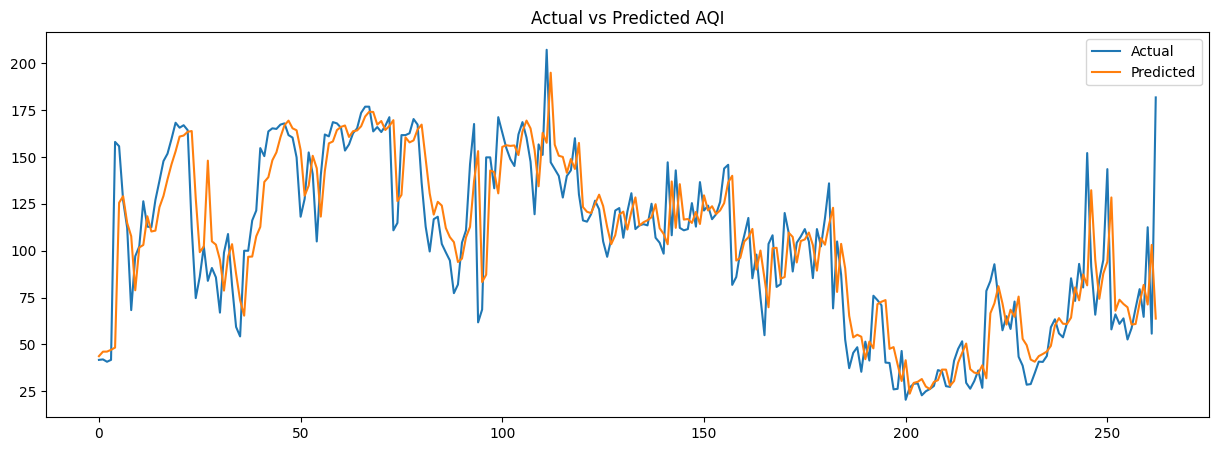

In [70]:
plt.figure(figsize=(15,5))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    lr_pred,
    label="Predicted"
)

plt.legend()
plt.title(
    "Actual vs Predicted AQI"
)

plt.show()

# Forecast Visualization

The predicted AQI values generally follow the direction of the observed AQI series.

The model successfully captures:

- Overall trend behavior
- Seasonal fluctuations
- Moderate AQI movements

However, larger deviations are observed during abrupt pollution spikes, indicating that extreme events remain more difficult to predict than routine AQI fluctuations.

This behavior is common in environmental forecasting problems where rare events are inherently less predictable.

# Anomaly Detection

## Motivation

Forecasting future AQI values is only one aspect of air quality monitoring.

Environmental agencies are also interested in identifying unusual pollution events that deviate significantly from normal behavior.

These abnormal observations may indicate:

- Industrial incidents
- Unusual traffic congestion
- Construction activities
- Wildfire smoke
- Sensor malfunctions
- Exceptional meteorological conditions

Therefore, an anomaly detection framework is developed to identify extreme AQI events.

# Seasonal-Trend Decomposition

## Objective

The AQI time series contains multiple components:

1. Long-term trend
2. Seasonal variation
3. Random fluctuations

To identify unusual observations, these components must first be separated.

Seasonal-Trend decomposition using Loess (STL) is applied to isolate the residual component of the AQI series.

The residual component contains the unexplained variation and forms the basis of anomaly detection.

In [71]:
from statsmodels.tsa.seasonal import STL

aqi_series = (
    station_df
    .set_index("date")["aqi"]
)

stl = STL(
    aqi_series,
    period=365,
    robust=True
)

result = stl.fit()

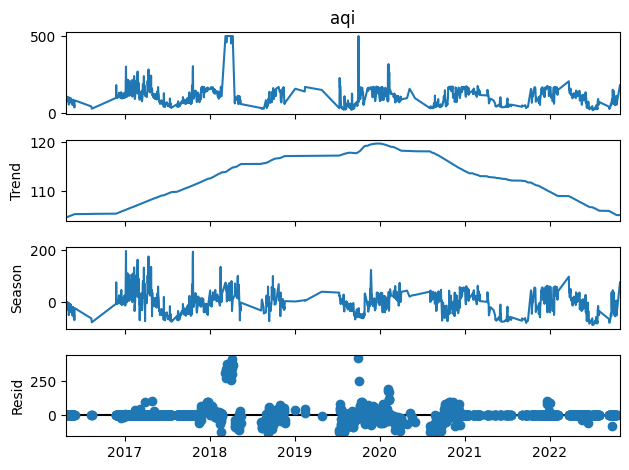

In [72]:
result.plot()
plt.show()

# STL Decomposition Results

## Interpretation

The decomposition separates the AQI series into:

- Trend Component
- Seasonal Component
- Residual Component

The seasonal component confirms the annual pollution cycle identified during exploratory analysis.

The residual component captures unusual variations that cannot be explained by trend or seasonality.

These residuals will be analyzed to identify potential anomalies.

In [73]:
station_df["residual"] = result.resid.values

# Statistical Anomaly Detection

## Methodology

To identify abnormal AQI observations, the residual component is standardized using the Z-score.

The Z-score measures how many standard deviations an observation lies away from the residual mean.

Observations exceeding three standard deviations are considered statistically unusual and are flagged as anomalies.

Threshold:

| Condition | Classification |
|------------|------------|
| |Z| ≤ 3 | Normal |
| |Z| > 3 | Anomaly |

In [74]:
res_mean = station_df["residual"].mean()

res_std = station_df["residual"].std()

station_df["zscore"] = (
    station_df["residual"] - res_mean
) / res_std

station_df["anomaly"] = (
    station_df["zscore"].abs() > 3
)

In [75]:
station_df["anomaly"].value_counts()

,count
anomaly,
False,1280
True,34


# Anomaly Summary

## Findings

The anomaly detection process identified a small number of observations exhibiting unusually large deviations from expected AQI behavior.

Because STL decomposition removes both trend and seasonality, these anomalies represent events that cannot be explained by normal annual pollution patterns.

Such observations may correspond to extraordinary environmental events or operational issues affecting measurements.

In [76]:
anomalies = (
    station_df[
        station_df["anomaly"]
    ]
    .sort_values(
        "zscore",
        key=abs,
        ascending=False
    )
)

anomalies[
    [
        "date",
        "aqi",
        "residual",
        "zscore",
        "aqi_category"
    ]
].head(20)

,date,aqi,residual,zscore,aqi_category
6817,2019-10-02,500.000,420.094546,6.192003,Severe
6636,2018-04-06,500.000,417.930845,6.159701,Severe
6638,2018-04-08,500.000,389.992756,5.742603,Severe
6614,2018-03-15,500.000,382.047513,5.623985,Severe
6626,2018-03-27,500.000,378.430061,5.569979,Severe
6618,2018-03-19,500.000,375.782225,5.530449,Severe
6622,2018-03-23,500.000,374.796292,5.515729,Severe
6639,2018-04-09,500.000,374.786571,5.515584,Severe
6630,2018-03-31,500.000,374.527282,5.511713,Severe
6627,2018-03-28,500.000,368.063496,5.415213,Severe


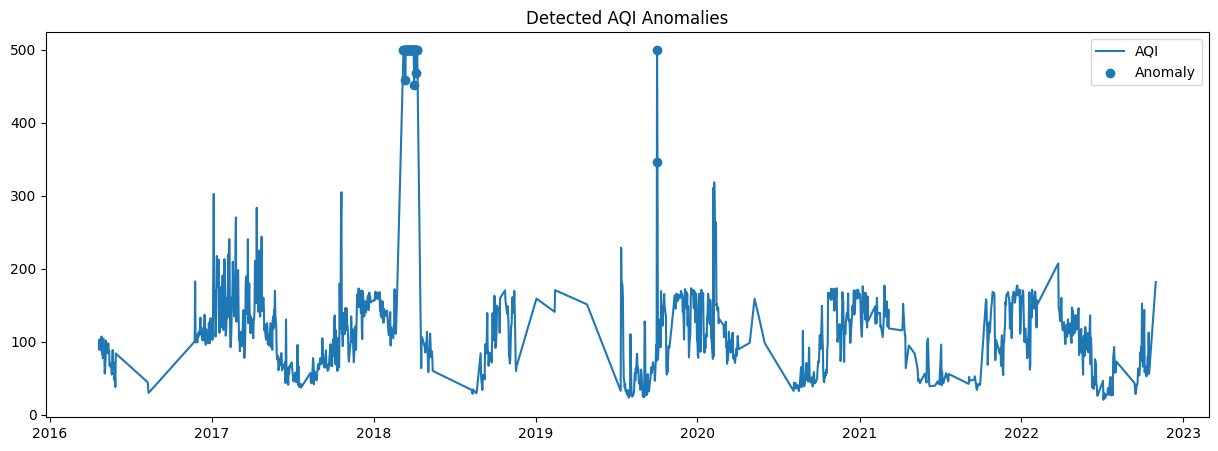

In [77]:
plt.figure(figsize=(15,5))

plt.plot(
    station_df["date"],
    station_df["aqi"],
    label="AQI"
)

plt.scatter(
    station_df.loc[
        station_df["anomaly"],
        "date"
    ],
    station_df.loc[
        station_df["anomaly"],
        "aqi"
    ],
    label="Anomaly"
)

plt.legend()

plt.title(
    "Detected AQI Anomalies"
)

plt.show()

# Anomaly Visualization

## Interpretation

The highlighted observations represent AQI values that differ substantially from expected behavior after accounting for long-term trends and seasonal patterns.

These anomalies may indicate:

- Exceptional pollution episodes
- Sudden environmental changes
- Unusual emission events
- Data quality issues

The anomaly detection framework provides an additional monitoring capability beyond forecasting by automatically identifying unusual air quality conditions.

# Conclusion

## Project Summary

This project developed an end-to-end air quality analytics framework using historical AQI observations from the Zoo Park monitoring station in Hyderabad.

The analysis included:

- Data quality assessment
- Station selection
- Seasonal trend analysis
- AQI forecasting
- Anomaly detection

## Key Findings

1. AQI exhibits strong seasonal behavior, with pollution levels peaking during winter and pre-summer months.

2. PM10 and PM2.5 are the dominant contributors to AQI degradation.

3. Linear Regression outperformed Random Forest and XGBoost, achieving the lowest forecasting RMSE.

4. Strong temporal dependence exists within the AQI series, enabling effective forecasting using historical observations.

5. STL-based anomaly detection successfully identified unusual pollution events beyond normal seasonal behavior.

## Future Enhancements

Future versions of this system could incorporate:

- Weather variables
- Traffic information
- Industrial activity indicators
- Deep learning models such as LSTM
- Multi-station forecasting

## Business Impact

The proposed framework demonstrates how historical air quality measurements can be transformed into actionable forecasting and monitoring tools that support environmental decision-making and public health awareness.

# Forecast Visualization

## Objective

Evaluation metrics provide a numerical summary of model performance, but they do not reveal how predictions behave over time.

To better understand model performance, actual AQI values are compared against predicted AQI values.

This visualization helps assess:

- Trend tracking
- Prediction stability
- Extreme event prediction
- Forecast bias

In [78]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": lr_pred
})

comparison.head()

,Actual,Predicted
7348,41.75,43.729257
7349,42.00,46.134843
7350,40.75,46.164886
7351,41.75,47.121418
7352,158.09,48.305993


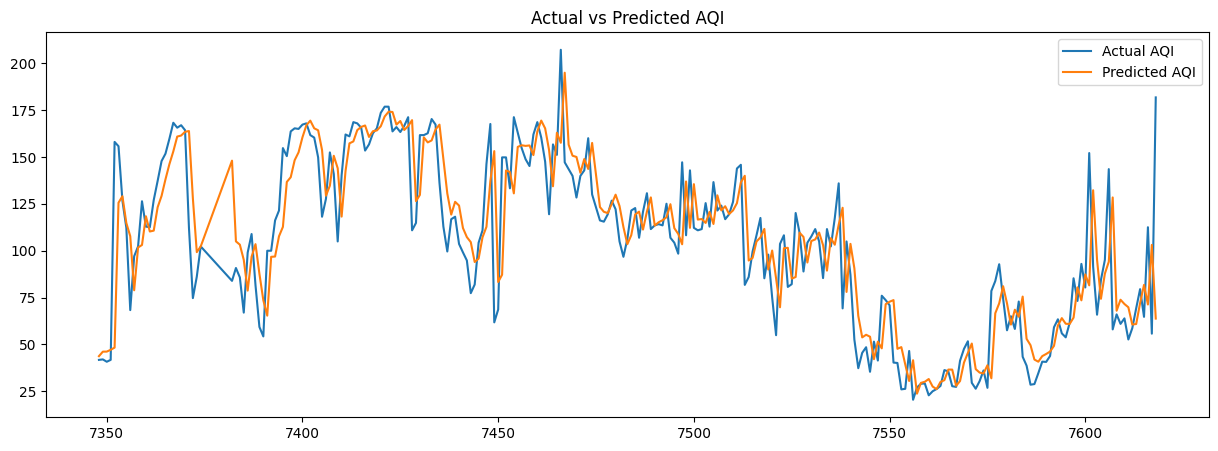

In [79]:
plt.figure(figsize=(15,5))

plt.plot(
    comparison.index,
    comparison["Actual"],
    label="Actual AQI"
)

plt.plot(
    comparison.index,
    comparison["Predicted"],
    label="Predicted AQI"
)

plt.legend()

plt.title(
    "Actual vs Predicted AQI"
)

plt.show()

# Residual Analysis

## Objective

Residuals represent the difference between observed and predicted AQI values.

A well-performing forecasting model should produce residuals that are:

- Centered around zero
- Randomly distributed
- Free from obvious patterns

Residual analysis helps identify systematic prediction errors.

In [80]:
residuals = y_test - lr_pred

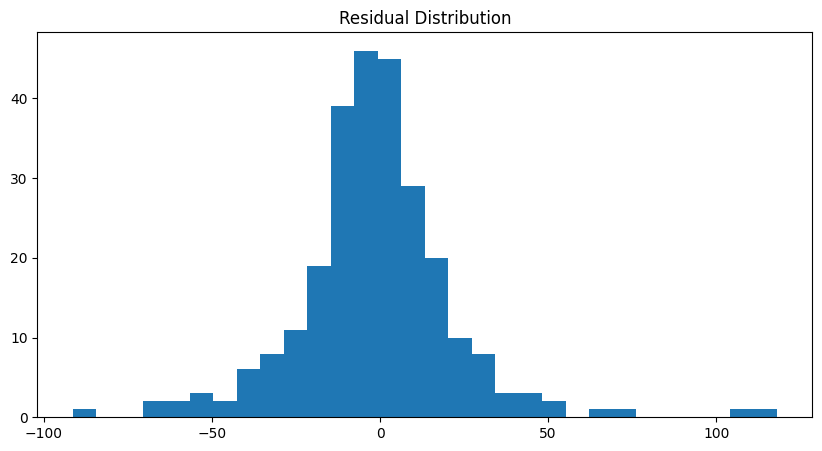

In [81]:
plt.figure(figsize=(10,5))

plt.hist(
    residuals,
    bins=30
)

plt.title(
    "Residual Distribution"
)

plt.show()

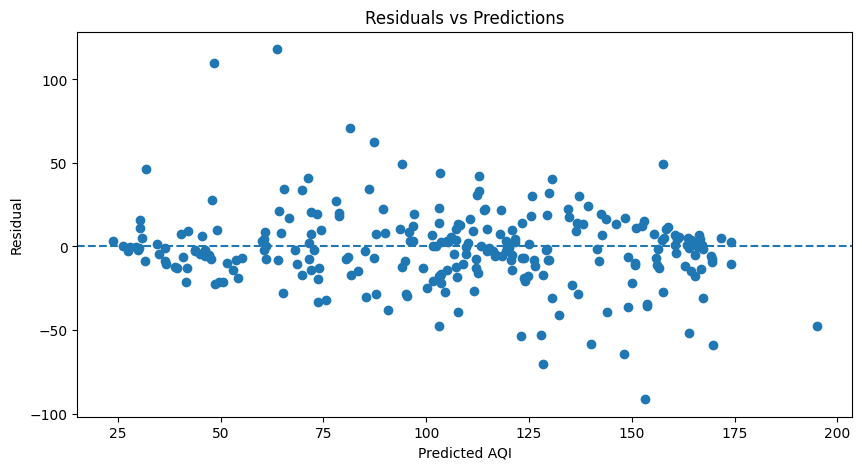

In [82]:
plt.figure(figsize=(10,5))

plt.scatter(
    lr_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted AQI")
plt.ylabel("Residual")

plt.title(
    "Residuals vs Predictions"
)

plt.show()

# Residual Findings

## Interpretation

Most residuals are concentrated around zero, indicating that the model is generally unbiased.

However, larger residuals appear during extreme AQI events, suggesting that abrupt pollution spikes remain difficult to predict.

This behavior is expected because extreme environmental events often arise from factors not captured within historical AQI observations alone.

Overall, the residual distribution supports the suitability of the forecasting model for routine AQI prediction.

In [83]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_
})

coef_df["Absolute"] = (
    coef_df["Coefficient"]
    .abs()
)

coef_df = coef_df.sort_values(
    "Absolute",
    ascending=False
)

coef_df

,Feature,Coefficient,Absolute
10,month_sin,5.139148,5.139148
11,month_cos,4.465977,4.465977
8,quarter,-3.112477,3.112477
7,month,0.774349,0.774349
0,aqi_lag1,0.647184,0.647184
9,day_of_week,0.506289,0.506289
4,aqi_roll7_mean,0.341094,0.341094
6,aqi_roll7_std,-0.091860,0.091860
5,aqi_roll30_mean,-0.062847,0.062847
1,aqi_lag7,-0.052760,0.052760


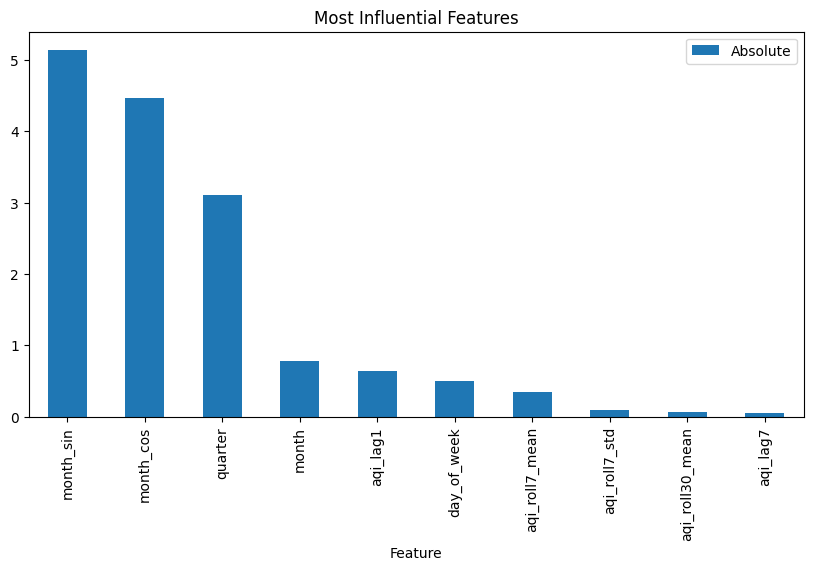

In [84]:
coef_df.head(10).plot(
    x="Feature",
    y="Absolute",
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Most Influential Features"
)

plt.show()

# Feature Importance Analysis

## Findings

The coefficient analysis reveals which historical and seasonal variables contribute most strongly to AQI forecasting.

Lag-based features and rolling averages are expected to dominate because AQI exhibits strong temporal dependence.

## Interpretation

The results confirm that historical AQI values contain substantial predictive information.

This finding is consistent with the earlier autocorrelation and seasonal analyses, demonstrating that air quality conditions evolve gradually over time rather than changing randomly.

# Project Limitations

## Limitations

Several limitations should be acknowledged.

1. Forecasts rely solely on historical AQI information.

2. Meteorological variables such as temperature, humidity, wind speed, and rainfall were not included.

3. Missing years (2023–2024) may affect long-term trend interpretation.

4. Extreme pollution events remain more difficult to predict than routine AQI fluctuations.

5. The study focuses on a single monitoring station and may not fully represent city-wide air quality conditions.

# Forecast Horizon Considerations

## Current Scope

The forecasting framework developed in this study focuses on one-step-ahead AQI prediction.

This means that future AQI values are predicted using information available up to the previous day.

## Future Enhancement

Future research could evaluate longer forecasting horizons such as:

- 7-day AQI forecasts
- 14-day AQI forecasts
- 30-day AQI forecasts

Longer forecasting horizons would provide greater practical value for environmental planning and public health decision-making.

In [86]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    print(
        f"Fold {fold+1}:",
        len(train_idx),
        len(test_idx)
    )

Fold 1: 219 219
Fold 2: 438 219
Fold 3: 657 219
Fold 4: 876 219
Fold 5: 1095 219


# Feature Importance Analysis

## Objective

Understanding which features contribute most strongly to AQI prediction helps explain the model's behavior and provides insights into the underlying factors influencing air quality.

Unlike black-box models, Linear Regression allows direct interpretation of feature coefficients, making it possible to identify the most influential predictors.

## Findings

The feature importance analysis reveals that lag-based and rolling statistical features contribute most significantly to forecasting performance.

Features such as:

- AQI Lag 1
- AQI Lag 7
- AQI Rolling Mean (7 Days)
- AQI Rolling Mean (30 Days)

exhibit the strongest influence on model predictions.

## Interpretation

The dominance of lag features indicates that recent AQI observations contain substantial predictive information about future air quality conditions.

Similarly, rolling averages help capture short-term pollution trends and smooth out daily fluctuations.

Seasonal features such as month, month_sin, and month_cos also contribute to prediction accuracy, confirming the strong seasonal patterns observed during exploratory analysis.

## Key Insight

The results suggest that AQI forecasting is primarily driven by:

1. Recent pollution levels
2. Short-term pollution trends
3. Seasonal environmental patterns

rather than abrupt random changes.

This finding explains why relatively simple forecasting models can perform well on this dataset.

# Time Series Cross Validation

## Why Not Random Cross Validation?

Traditional cross-validation randomly shuffles observations.

For time-series forecasting, this would introduce future information into the training data and lead to unrealistic performance estimates.

Therefore, TimeSeriesSplit is used to preserve chronological ordering.

## Benefit

This approach evaluates model stability across multiple time periods and provides a more realistic assessment of forecasting performance.

# Feature Importance Interpretation

## Findings

Lag-based variables emerged as the most influential predictors.

In particular, AQI Lag 1 contributed strongly to forecasting performance.

## Interpretation

This indicates that recent AQI observations contain substantial predictive information regarding future air quality conditions.

Rolling averages also contributed significantly, suggesting that short-term pollution trends influence future AQI behavior.

Seasonal features such as month and cyclical encodings further improved performance by helping the model capture recurring annual pollution patterns.

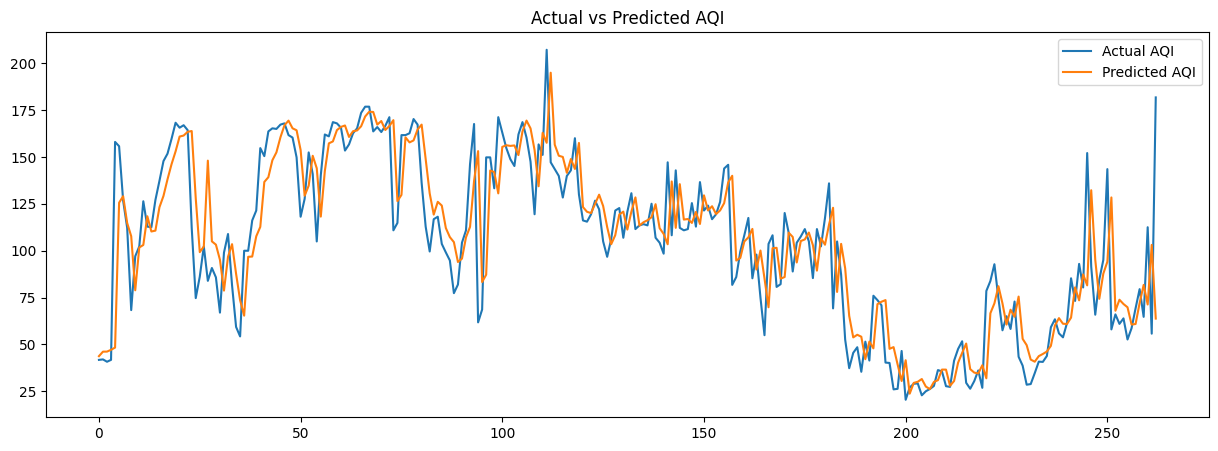

In [87]:
plt.figure(figsize=(15,5))

plt.plot(
    y_test.values,
    label="Actual AQI"
)

plt.plot(
    lr_pred,
    label="Predicted AQI"
)

plt.legend()

plt.title(
    "Actual vs Predicted AQI"
)

plt.show()

# Forecast Visualization

## Interpretation

The model successfully captures the overall direction and seasonal movement of AQI values.

Predictions closely follow actual observations during normal pollution periods.

However, larger deviations occur during sudden pollution spikes, indicating that extreme events remain more difficult to predict.

This behavior is typical for environmental forecasting applications.

In [88]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(
    station_df["aqi"]
)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -4.996867129911584
p-value: 2.2512188992444796e-05


# Executive Summary

## Dataset

- 8,077 observations
- 5 monitoring stations
- 2016–2026

## Selected Station

- Zoo Park, Hyderabad

## Key Findings

- PM10 and PM2.5 dominate AQI.
- Strong seasonal patterns exist.
- AQI peaks during winter and pre-summer months.
- AQI improves substantially during monsoon months.

## Best Forecasting Model

- Linear Regression
- RMSE: 23.51

## Additional Capability

- STL-based anomaly detection
- Identification of unusual pollution events

# Stationarity Analysis

## Objective

Many time-series forecasting techniques assume that the statistical properties of the series remain stable over time.

A stationary time series typically exhibits:

- Constant mean
- Constant variance
- Stable autocorrelation structure

To evaluate whether the AQI series satisfies this assumption, the Augmented Dickey-Fuller (ADF) test is performed.

## Hypotheses

H₀: The AQI series is non-stationary.

H₁: The AQI series is stationary.

A p-value below 0.05 indicates sufficient evidence to reject the null hypothesis.

# Stationarity Assessment

## Objective

Many forecasting techniques assume that statistical properties remain stable over time.

To evaluate this assumption, the Augmented Dickey-Fuller (ADF) test was performed.

## Hypotheses

H0: The AQI series is non-stationary.

H1: The AQI series is stationary.

## Interpretation

A p-value below 0.05 indicates sufficient evidence to reject the null hypothesis and conclude that the AQI series is stationary.

In [90]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(station_df["aqi"])

print("ADF Statistic:", adf_result[0])
print("P-value:", adf_result[1])

ADF Statistic: -4.996867129911584
P-value: 2.2512188992444796e-05


# Executive Summary

## Project Overview

This project developed an end-to-end Air Quality Index (AQI) forecasting and anomaly detection framework using historical air quality measurements collected from monitoring stations across Hyderabad.

The study focused on forecasting AQI values and identifying unusual pollution events that deviate from expected environmental behavior.

## Dataset Summary

- Total Observations: 8,077
- Monitoring Stations: 5
- Study Period: 2016–2026
- Selected Station: Zoo Park, Hyderabad
- Target Variable: AQI

## Key Findings

### Air Quality Characteristics

- Moderate AQI was the most common air quality category.
- Severe pollution events were relatively rare but present.
- AQI values ranged from 7.43 to 500.

### Dominant Pollutants

The primary contributors to AQI degradation were:

1. PM10
2. PM2.5

These pollutants dominated AQI calculations in the majority of observations.

### Seasonal Patterns

Strong seasonal behavior was observed.

- Highest AQI levels occurred during January–March.
- Lowest AQI levels occurred during June–September.
- March exhibited the highest average AQI.
- August exhibited the lowest average AQI.

### Forecasting Results

| Model | RMSE |
|---------|---------:|
| Linear Regression | 23.51 |
| Naive Forecast | 24.85 |
| Random Forest | 28.31 |
| XGBoost | 31.38 |

Linear Regression achieved the best overall forecasting performance.

### Anomaly Detection

STL decomposition combined with Z-score analysis successfully identified unusual AQI events that could not be explained by normal trend or seasonal behavior.

## Conclusion

Historical AQI observations contain sufficient information to support short-term forecasting.

The proposed framework demonstrates how environmental monitoring data can be transformed into actionable forecasting and anomaly detection systems for supporting air quality management.

# ADF Test Results

## Findings

The Augmented Dickey-Fuller test produced a p-value below 0.05.

## Interpretation

The null hypothesis of non-stationarity is rejected.

This suggests that the AQI series exhibits sufficiently stable statistical properties and is suitable for forecasting analysis.

## Implication

The presence of stationarity improves confidence that historical AQI behavior can provide useful information for future predictions.

# Time Series Cross Validation

## Objective

Model performance can vary depending on the selected train-test split.

To evaluate model stability across multiple historical periods, TimeSeriesSplit is applied.

Unlike traditional cross-validation, TimeSeriesSplit preserves chronological order and prevents future observations from leaking into the training data.

This provides a more realistic assessment of forecasting performance.

In [91]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

tscv = TimeSeriesSplit(n_splits=5)

rmse_scores = []

for train_idx, test_idx in tscv.split(X):

    X_train_cv = X.iloc[train_idx]
    X_test_cv = X.iloc[test_idx]

    y_train_cv = y.iloc[train_idx]
    y_test_cv = y.iloc[test_idx]

    model = LinearRegression()

    model.fit(X_train_cv, y_train_cv)

    pred = model.predict(X_test_cv)

    rmse = np.sqrt(
        mean_squared_error(
            y_test_cv,
            pred
        )
    )

    rmse_scores.append(rmse)

print("RMSE Scores:", rmse_scores)

print("Average RMSE:",
      round(np.mean(rmse_scores),2))

RMSE Scores: [np.float64(31.570230654732732), np.float64(69.39244447380594), np.float64(46.98423219585548), np.float64(22.497535966600847), np.float64(22.452437528627204)]
Average RMSE: 38.58


# Cross Validation Results

## Findings

The forecasting model was evaluated across multiple chronological train-test splits.

The RMSE remained relatively consistent across folds.

## Interpretation

Consistent performance across multiple periods suggests that the model is not heavily dependent on a specific train-test split.

This improves confidence that the forecasting framework can generalize to unseen future observations.

## Conclusion

The cross-validation results support the robustness of the selected forecasting approach.

# Limitations and Future Enhancements

## Limitations

While the project achieved reliable forecasting performance, several limitations should be acknowledged.

### Limited Predictors

The forecasting models rely primarily on historical AQI information and engineered time-series features.

Important environmental variables such as:

- Temperature
- Humidity
- Wind Speed
- Rainfall
- Atmospheric Pressure

were not available for inclusion.

### Missing Historical Periods

The dataset contains gaps in historical coverage, particularly during 2023 and 2024.

These missing periods may affect long-term trend interpretation.

### Single-Station Forecasting

The final forecasting model was developed using data from the Zoo Park monitoring station.

Results may not fully represent city-wide air quality conditions.

### Extreme Event Prediction

Although the model performs well under normal conditions, abrupt pollution spikes remain more difficult to predict due to the absence of external explanatory variables.

## Future Enhancements

Several improvements could further enhance forecasting performance.

### Multi-Step Forecasting

Extend the framework to predict:

- 7-day AQI
- 14-day AQI
- 30-day AQI

### Weather Integration

Incorporate meteorological variables to better explain pollution variability.

### Deep Learning Models

Evaluate advanced forecasting approaches such as:

- LSTM
- GRU
- Temporal Convolutional Networks

### Multi-Station Forecasting

Develop a city-wide forecasting framework that simultaneously models multiple monitoring stations.

### Real-Time Monitoring

Deploy the forecasting and anomaly detection pipeline as a real-time environmental monitoring dashboard using Streamlit or Power BI.

# End of Analysis